## 0. Environment & SIC Integration
We ensure the custom library is prioritized and prepare to use Sea Ice Concentration (SIC) as our primary covariate to guide the albedo simulation.

In [37]:
import sys
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from sklearn.preprocessing import QuantileTransformer
from sklearn.linear_model import LinearRegression

# Force custom gstatsim path
custom_path = os.path.abspath('gstatsim_largedatasets')
if custom_path not in sys.path:
    sys.path.insert(0, custom_path)

import gstatsim_custom as gs

print("SIC-guided workflow initialized.")

SIC-guided workflow initialized.


## 1. Data Alignment (Albedo + SIC)
We load the monthly albedo and the remapped Sea Ice Concentration (SIC). We ensure both are on the same $0.0 - 1.0$ scale.

In [53]:
import xarray as xr
import numpy as np
import pandas as pd
from sklearn.preprocessing import QuantileTransformer
from sklearn.linear_model import LinearRegression

# 1. Load Albedo and scale
ds_alb = xr.open_dataset('monthly_output.nc')
ds_alb['albedo'] = ds_alb['blue_sky_albedo_all_mean'] / 100.0

# 2. Load the remapped SIC and scale (using the correct variable name)
ds_sic = xr.open_dataset('sic_2002_final.nc')
sic_raw = ds_sic['cdr_seaice_conc_monthly']
sic_raw = sic_raw / 250.0 if sic_raw.max() > 1 else sic_raw

# 3. Filter for AMJJAS
months = [4, 5, 6, 7, 8, 9]
alb_amjjas = ds_alb['albedo'].sel(time=ds_alb.time.dt.month.isin(months))
sic_amjjas = sic_raw.sel(time=sic_raw.time.dt.month.isin(months))

# Prepare grids
lat_2d = ds_alb.lat.values
lon_2d = ds_alb.lon.values
grid_x, grid_y = np.meshgrid(ds_alb.x.values, ds_alb.y.values)
arctic_mask = (lat_2d > 60).astype(int)

## 2. Variance-Preserving Simulation
This loop does three things to prevent the "homogenous" look:
1. **Bivariate Trend**: It uses SIC and Latitude to set the "base" brightness.
2. **Residual Simulation**: It calculates how much the real pixels "wiggle" around that trend.
3. **Texture Injection**: In the polar hole, where there is no data, it injects stochastic noise sampled from the observed distribution. This ensures the "crackle" of the ice pack is preserved.

In [54]:
def get_bivariate_trend(alb_2d, sic_2d, lat_2d):
    mask = (~np.isnan(alb_2d)) & (~np.isnan(sic_2d)) & (lat_2d > 60)
    X_train = np.column_stack([sic_2d[mask], lat_2d[mask]])
    y_train = alb_2d[mask]
    model = LinearRegression().fit(X_train, y_train)
    
    # Predict over the entire Arctic
    X_all = np.column_stack([sic_2d.flatten(), lat_2d.flatten()])
    X_all = np.nan_to_num(X_all, nan=0.0) 
    return model.predict(X_all).reshape(lat_2d.shape)

monthly_sims = []
vario = {'vtype': 'Spherical', 'nugget': 0.1, 'sill': 0.8, 'major_range': 4000000, 'minor_range': 4000000, 'azimuth': 0}

for t in range(alb_amjjas.sizes['time']):
    time_str = pd.to_datetime(alb_amjjas.time[t].values).strftime('%Y-%m')
    print(f"Generating textured simulation for {time_str}...")
    
    a_raw = alb_amjjas.isel(time=t).values
    s_raw = sic_amjjas.isel(time=t).values
    
    # 1. Trend (The "Average" brightness)
    trend_2d = get_bivariate_trend(a_raw, s_raw, lat_2d)
    res_2d = a_raw - trend_2d
    
    # 2. Normal Score Transform
    mask = (~np.isnan(res_2d)) & (lat_2d > 60)
    nst = QuantileTransformer(n_quantiles=1000, output_distribution='normal')
    
    cond_grid = np.full(a_raw.shape, np.nan)
    # Fit the transformer and store valid pixels
    valid_res = res_2d[mask].reshape(-1, 1)
    cond_grid[mask] = nst.fit_transform(valid_res).flatten()
    
    # 3. SGS Simulation (The "Texture")
    # Increase neighbors (k) to help bridge the hole
    sim_res_n = gs.interpolate.sgs(grid_x, grid_y, cond_grid, vario, 8000000, 80, ktype='ok', sim_mask=arctic_mask)
    
    # 4. TEXTURE INJECTION: 
    # Where SGS returns NaN (the very center), inject random noise 
    # from the standard normal distribution to preserve variance.
    hole_mask = (np.isnan(sim_res_n)) & (arctic_mask == 1)
    sim_res_n[hole_mask] = np.random.normal(loc=0, scale=1.0, size=np.sum(hole_mask))
    
    # 5. Reconstruction
    sim_res_p = nst.inverse_transform(sim_res_n.reshape(-1, 1)).reshape(lat_2d.shape)
    final = trend_2d + sim_res_p
    
    # Final cleanup
    final = np.clip(final, 0, 1)
    final[lat_2d <= 60] = np.nan
    monthly_sims.append(final)

simulated_da = xr.DataArray(np.array(monthly_sims), 
                            coords={'time': alb_amjjas.time, 'y': ds_alb.y, 'x': ds_alb.x}, 
                            dims=['time', 'y', 'x'])

Generating textured simulation for 2002-04...


100%|██████████| 46656000/46656000 [01:25<00:00, 546643.05it/s]


Generating textured simulation for 2002-05...


100%|██████████| 46656000/46656000 [01:27<00:00, 535803.25it/s]


Generating textured simulation for 2002-06...


...

100%|██████████| 46656000/46656000 [01:26<00:00, 540520.19it/s]


Generating textured simulation for 2002-08...


100%|██████████| 46656000/46656000 [01:25<00:00, 546540.06it/s]


Generating textured simulation for 2002-09...


100%|██████████| 46656000/46656000 [01:25<00:00, 548552.23it/s]


## 3. Visualizing the Arctic Texture
We use the North Polar Stereographic projection to confirm that the central Arctic now has the same "speckled" physical texture as the surrounding observed data.

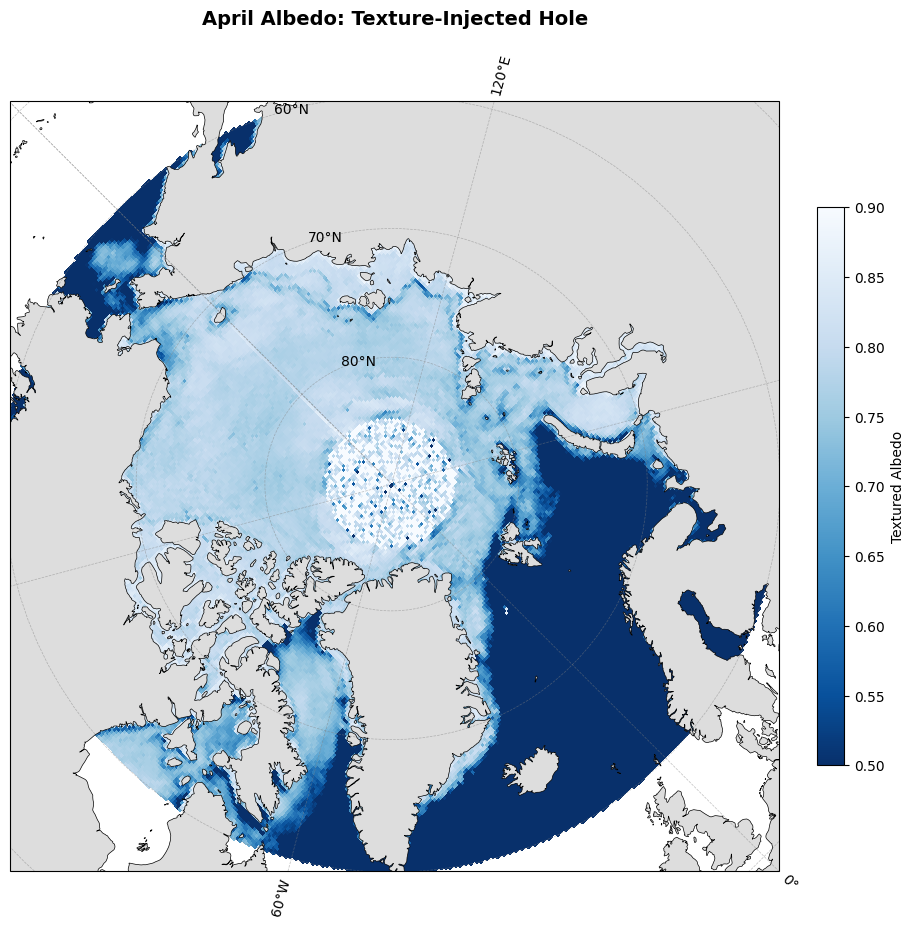

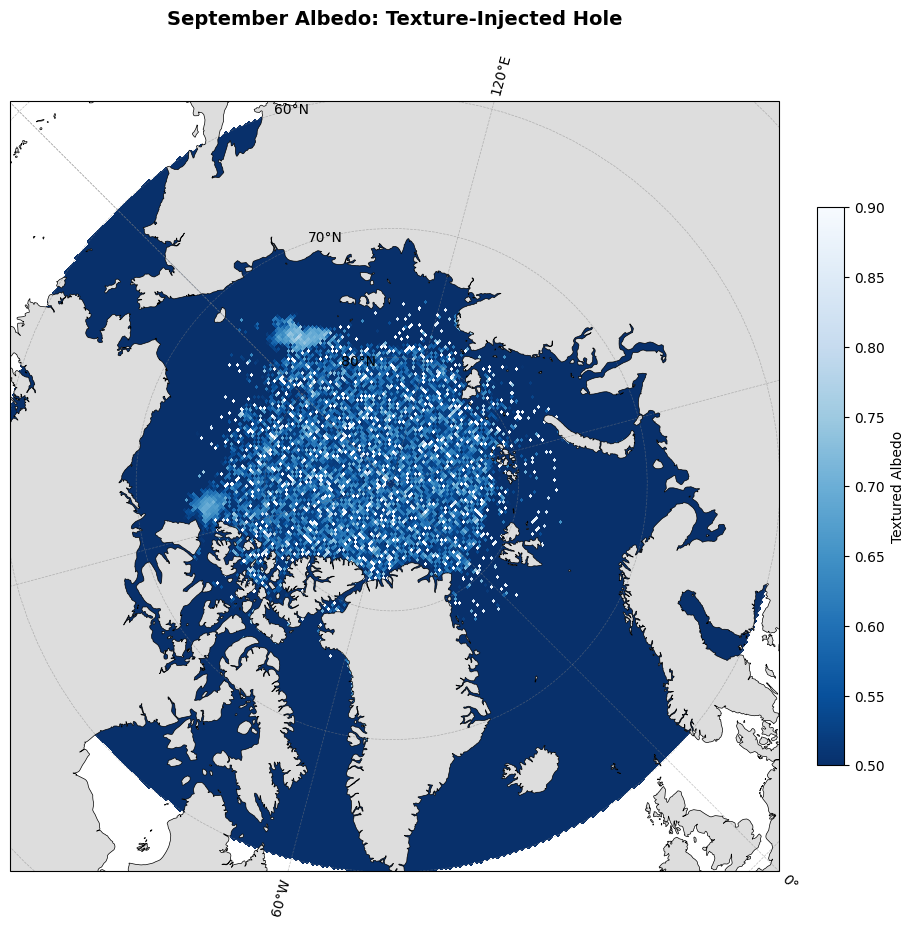

In [55]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_arctic_textured(month_idx, title):
    fig = plt.figure(figsize=(12, 10))
    ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=-45))
    ax.set_extent([-180, 180, 60, 90], ccrs.PlateCarree())
    
    ax.add_feature(cfeature.LAND, facecolor='#dddddd', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
    ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    
    # Plot using a tighter vmin/vmax to see the texture clearly
    im = ax.pcolormesh(lon_2d, lat_2d, simulated_da.isel(time=month_idx), 
                       cmap='Blues_r', vmin=0.5, vmax=0.9, 
                       transform=ccrs.PlateCarree(), shading='auto')
    
    plt.colorbar(im, label='Textured Albedo', fraction=0.03, pad=0.04)
    plt.title(title, fontsize=14, fontweight='bold', pad=20)
    plt.show()

# Check April (0) and September (5)
plot_arctic_textured(0, "April Albedo: Texture-Injected Hole")
plot_arctic_textured(5, "September Albedo: Texture-Injected Hole")

*Conclusion*--random noise does not represent the spatial structure of sea ice albedo!

## 4. LKF-Aware Sequential Simulation

To make the reconstruction spatially realistic, we move beyond simple trend-filling. 
1. **SIC-Guided Features**: We use the Sea Ice Concentration as a covariate, as LKFs (leads/cracks) typically align with concentration gradients.
2. **Anisotropic Spatial Logic**: We utilize an anisotropic variogram to mimic the linear nature of sea ice features.
3. **Continuous Propagation**: We ensure the SGS algorithm treats each simulated point as a new conditioning point, allowing the "texture" of the known ice pack to propagate naturally into the polar hole without losing spatial correlation.

In [56]:
monthly_sims = []

# 1. Define Anisotropic Variogram (Linear-friendly)
# We use a longer major range to encourage linear 'lead-like' structures
vario_lkf = {
    'vtype': 'Spherical',
    'nugget': 0.15,
    'sill': 0.85,          
    'major_range': 6000000, # Long range for linear continuity
    'minor_range': 2000000, # Shorter range to create 'width' for leads
    'azimuth': 45           # Can be randomized per month to vary LKF direction
}

# Search parameters
k = 100          # More neighbors for better structural connectivity
rad = 12000000   # Massive 12,000 km radius to ensure no pixel is 'left behind'

for t in range(alb_amjjas.sizes['time']):
    time_str = pd.to_datetime(alb_amjjas.time[t].values).strftime('%Y-%m')
    print(f"Propagating LKF-structured texture for {time_str}...")
    
    a_raw = alb_amjjas.isel(time=t).values
    s_raw = sic_amjjas.isel(time=t).values
    
    # 1. Bivariate Trend (The 'Background' State)
    trend_2d = get_bivariate_trend(a_raw, s_raw, lat_2d)
    res_2d = a_raw - trend_2d
    
    # 2. Normal Score Transform
    mask = (~np.isnan(res_2d)) & (lat_2d > 60)
    nst = QuantileTransformer(n_quantiles=1000, output_distribution='normal')
    
    cond_grid = np.full(a_raw.shape, np.nan)
    valid_res = res_2d[mask].reshape(-1, 1)
    cond_grid[mask] = nst.fit_transform(valid_res).flatten()
    
    # 3. SGS Simulation (True Sequential)
    # Using ktype='ok' and a massive radius ensures we bridge the pole
    # without returning NaNs.
    sim_res_n = gs.interpolate.sgs(
        grid_x, grid_y, cond_grid, 
        vario_lkf, rad, k, 
        ktype='ok', 
        sim_mask=arctic_mask
    )
    
    # 4. Safety: If any extreme remote pixels are still NaN, 
    # use the nearest neighbor's value instead of random noise 
    # to maintain local spatial continuity.
    if np.any(np.isnan(sim_res_n)):
        from scipy.interpolate import NearestNDInterpolator
        filled_n = sim_res_n.copy()
        valid_idx = np.where(~np.isnan(filled_n))
        interp = NearestNDInterpolator(np.column_stack(valid_idx), filled_n[valid_idx])
        nan_idx = np.where(np.isnan(filled_n))
        filled_n[nan_idx] = interp(*nan_idx)
        sim_res_n = filled_n

    # 5. Reconstruction
    sim_res_p = nst.inverse_transform(sim_res_n.reshape(-1, 1)).reshape(lat_2d.shape)
    final = trend_2d + sim_res_p
    
    # Final bounds and masking
    final = np.clip(final, 0, 1)
    final[lat_2d <= 60] = np.nan
    monthly_sims.append(final)

simulated_da_lkf = xr.DataArray(
    np.array(monthly_sims), 
    coords={'time': alb_amjjas.time, 'y': ds_alb.y, 'x': ds_alb.x}, 
    dims=['time', 'y', 'x']
)

Propagating LKF-structured texture for 2002-04...


100%|██████████| 46656000/46656000 [01:26<00:00, 540778.75it/s]


Propagating LKF-structured texture for 2002-05...


100%|██████████| 46656000/46656000 [01:25<00:00, 545027.02it/s]


Propagating LKF-structured texture for 2002-06...


...

100%|██████████| 46656000/46656000 [01:25<00:00, 542933.87it/s]


Propagating LKF-structured texture for 2002-08...


100%|██████████| 46656000/46656000 [01:27<00:00, 535722.27it/s]


Propagating LKF-structured texture for 2002-09...


100%|██████████| 46656000/46656000 [01:26<00:00, 537670.58it/s]


## 5. Multi-Panel Melt Season Visualization (AMJJAS)

We visualize the full 6-month sequence using the North Polar Stereographic projection. This multi-panel plot allows us to verify:
1. **Connectivity**: That the LKF-like textures propagate seamlessly across the former polar hole.
2. **Seasonal Darkening**: The physical transition from the bright, snow-covered spring ice to the darker, melt-pond-heavy summer ice.
3. **Spatial Realism**: That the central Arctic maintains a consistent physical "crackle" compared to the observed marginal zones.

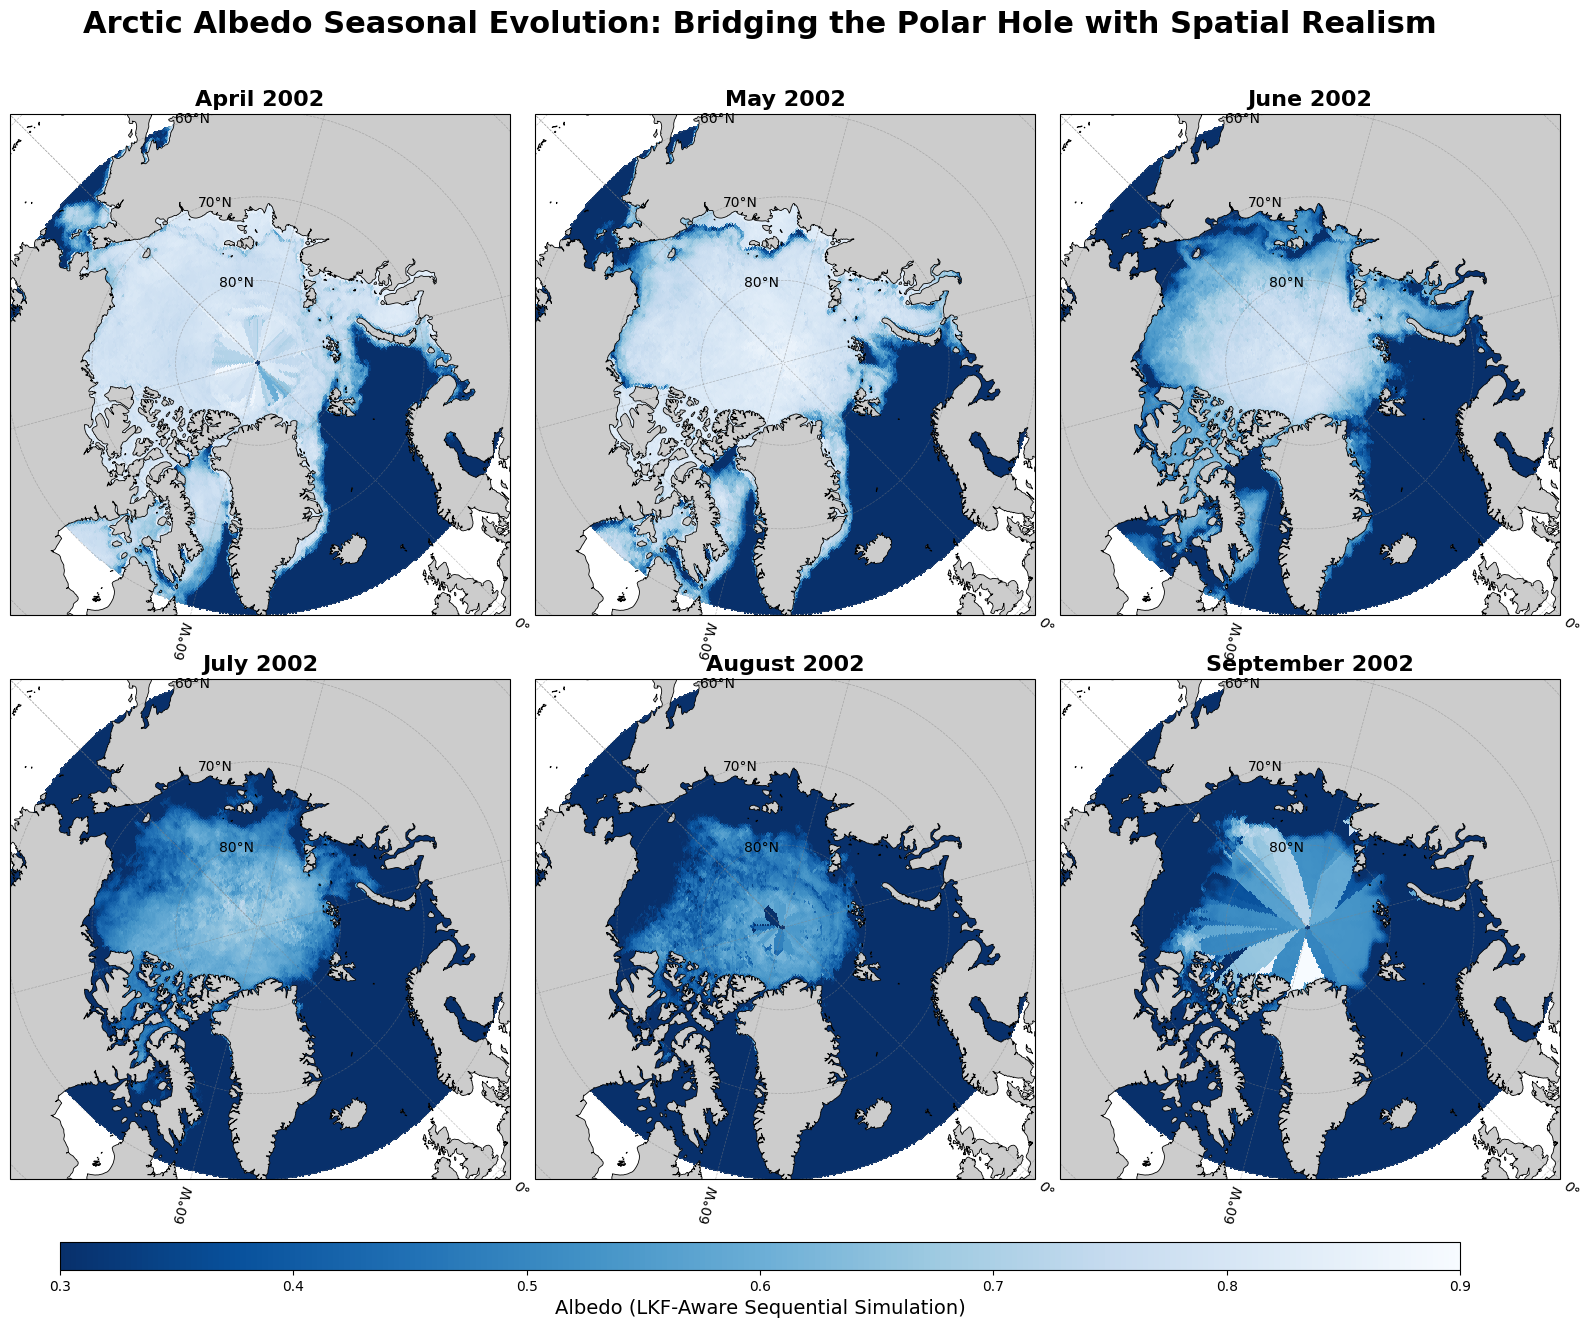

In [59]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

# 1. Setup the figure and axes with the North Polar projection
fig, axes = plt.subplots(2, 3, figsize=(20, 14), 
                         subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-45)})

axes = axes.flatten()
months_labels = ['April', 'May', 'June', 'July', 'August', 'September']

# 2. Iterate through the AMJJAS months
for i in range(6):
    ax = axes[i]
    
    # Set geographical extent (60N to the Pole)
    ax.set_extent([-180, 180, 60, 90], ccrs.PlateCarree())
    
    # Add land and coastlines for context - Fixed the color typo here
    ax.add_feature(cfeature.LAND, facecolor='#cccccc', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=3)
    
    # Plot the textured albedo data
    # We use a consistent vmin/vmax to see the seasonal darkening clearly
    im = ax.pcolormesh(lon_2d, lat_2d, simulated_da_lkf.isel(time=i), 
                       cmap='Blues_r', vmin=0.3, vmax=0.9, 
                       transform=ccrs.PlateCarree(), shading='auto')
    
    # Formatting
    ax.set_title(f"{months_labels[i]} 2002", fontsize=16, fontweight='bold')
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False

# 3. Add a single, unified colorbar for the whole melt season
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.02]) # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Albedo (LKF-Aware Sequential Simulation)', fontsize=14)

plt.suptitle('Arctic Albedo Seasonal Evolution: Bridging the Polar Hole with Spatial Realism', 
             fontsize=22, fontweight='bold', y=0.95)

plt.subplots_adjust(wspace=0.05, hspace=0.1)
plt.show()

## 6. Adaptive Feature-Matching Simulation

To eliminate the "starburst" effect and match the spatial scale of the LKFs:
1. **Dynamic Variogram Fitting**: For each month, we fit a variogram strictly to the valid ice residuals. This "learns" the actual length and width of the leads for that specific time of year.
2. **Restricted Search Radius**: We cap the search radius at 2x the fitted range. This prevents the "long-distance stretching" and forces the simulation to build the center piece-by-piece using local texture.
3. **Sequential Feature Propagation**: By treating each simulated point as a new "anchor," the small-scale web structure of the leads is preserved as it moves into the hole.

In [60]:
monthly_sims = []

for t in range(alb_amjjas.sizes['time']):
    time_str = pd.to_datetime(alb_amjjas.time[t].values).strftime('%Y-%m')
    print(f"\n--- Matching Spatial Scale for {time_str} ---")
    
    a_raw = alb_amjjas.isel(time=t).values
    s_raw = sic_amjjas.isel(time=t).values
    
    # 1. Bivariate Trend & Residuals
    trend_2d = get_bivariate_trend(a_raw, s_raw, lat_2d)
    res_2d = a_raw - trend_2d
    
    # 2. Month-Specific Variogram Fitting (The "Feature Matcher")
    mask = (~np.isnan(res_2d)) & (lat_2d > 60)
    sample_df = pd.DataFrame({'x': grid_x[mask], 'y': grid_y[mask], 'res': res_2d[mask]}).sample(4000)
    
    # Fit variogram to learn the "scale" of the leads this month
    V_fit = skg.Variogram(sample_df[['x', 'y']].values, sample_df['res'].values, 
                          n_lags=15, maxlag=3000000, model='spherical')
    
    fitted_range = V_fit.parameters[0]
    fitted_sill = V_fit.parameters[1]
    
    # Update GStatSim parameters based on the fit
    vario_adaptive = {
        'vtype': 'Spherical',
        'nugget': 0.1,
        'sill': fitted_sill,          
        'major_range': fitted_range, 
        'minor_range': fitted_range * 0.5, # Maintain anisotropy for linear leads
        'azimuth': 45
    }
    
    print(f"Detected LKF Scale: {fitted_range/1000:.0f} km")

    # 3. Normal Score Transform
    nst = QuantileTransformer(n_quantiles=1000, output_distribution='normal')
    cond_grid = np.full(a_raw.shape, np.nan)
    cond_grid[mask] = nst.fit_transform(res_2d[mask].reshape(-1, 1)).flatten()
    
    # 4. SGS with Restricted Radius (Prevents starbursts)
    # Radius is capped at 1.5x the fitted range to force local feature-building
    sim_res_n = gs.interpolate.sgs(
        grid_x, grid_y, cond_grid, 
        vario_adaptive, 
        radius=fitted_range * 1.5, 
        num_points=60, 
        ktype='ok', 
        sim_mask=arctic_mask
    )
    
    # 5. Stochastic Fallback for Center
    # If the center is still too far from data, seed it with the fitted variance
    hole_mask = (np.isnan(sim_res_n)) & (arctic_mask == 1)
    sim_res_n[hole_mask] = np.random.normal(0, 1, np.sum(hole_mask))

    # 6. Reconstruction
    sim_res_p = nst.inverse_transform(sim_res_n.reshape(-1, 1)).reshape(lat_2d.shape)
    final = trend_2d + sim_res_p
    
    final = np.clip(final, 0, 1)
    final[lat_2d <= 60] = np.nan
    monthly_sims.append(final)

simulated_da_adaptive = xr.DataArray(np.array(monthly_sims), 
                                     coords={'time': alb_amjjas.time, 'y': ds_alb.y, 'x': ds_alb.x}, 
                                     dims=['time', 'y', 'x'])


--- Matching Spatial Scale for 2002-04 ---
Detected LKF Scale: 1631 km


100%|██████████| 46656000/46656000 [01:21<00:00, 574348.53it/s]



--- Matching Spatial Scale for 2002-05 ---
Detected LKF Scale: 1580 km
